In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem Setup
def generate_problem(n, d):
    Q = [np.eye(d) + 0.1 * np.random.randn(d, d) for _ in range(n)]
    Q = [(Qi.T @ Qi) + 0.5 * np.eye(d) for Qi in Q]  # make PD
    a = [np.random.randn(d) for _ in range(n)]

    def grad_fi(i, x):
        return Q[i] @ (x - a[i])

    def f_i(i, x):
        return 0.5 * (x - a[i]).T @ Q[i] @ (x - a[i])

    return Q, a, grad_fi, f_i


def compute_global_optimum(Q, a):
    Q_sum = sum(Q)
    Qa_sum = sum(Q[i] @ a[i] for i in range(len(Q)))
    x_star = np.linalg.solve(Q_sum, Qa_sum)
    return x_star

# Graph + Mixing Matrix
def ring_graph(n):
    W = np.zeros((n, n))
    for i in range(n):
        W[i, i] = 0.5
        W[i, (i - 1) % n] = 0.25
        W[i, (i + 1) % n] = 0.25
    return W

# Metrics
def compute_metrics(X, x_star, f_i):
    n = X.shape[0]
    x_bar = np.mean(X, axis=0)

    # distance to optimum
    dist = np.linalg.norm(x_bar - x_star)

    # consensus error
    cons = np.sqrt(np.sum(np.linalg.norm(X - x_bar, axis=1) ** 2))

    # objective gap
    f_val = sum(f_i(i, x_bar) for i in range(n)) / n
    f_star = sum(f_i(i, x_star) for i in range(n)) / n
    gap = f_val - f_star

    return dist, cons, gap

# DGD
def run_dgd(W, grad_fi, X0, alpha, K):
    n, d = X0.shape
    X = X0.copy()
    history = []

    for k in range(K):
        grad = np.array([grad_fi(i, X[i]) for i in range(n)])
        X = W @ X - alpha * grad
        history.append(X.copy())

    return history


# EXTRA
def run_extra(W, grad_fi, X0, alpha, K):
    n, d = X0.shape
    W_bar = 0.5 * (np.eye(n) + W)

    X_prev = X0.copy()
    grad_prev = np.array([grad_fi(i, X_prev[i]) for i in range(n)])

    X = W @ X_prev - alpha * grad_prev
    history = [X_prev.copy(), X.copy()]

    for k in range(1, K):
        grad = np.array([grad_fi(i, X[i]) for i in range(n)])

        X_new = (np.eye(n) + W) @ X - W_bar @ X_prev \
                - alpha * (grad - grad_prev)

        X_prev = X
        X = X_new
        grad_prev = grad

        history.append(X.copy())

    return history


# DIGing
def run_diging(W, grad_fi, X0, alpha, K):
    n, d = X0.shape
    X = X0.copy()

    Y = np.array([grad_fi(i, X[i]) for i in range(n)])

    history = [X.copy()]

    for k in range(K):
        X_new = W @ X - alpha * Y
        grad_new = np.array([grad_fi(i, X_new[i]) for i in range(n)])

        Y = W @ Y + (grad_new - np.array([grad_fi(i, X[i]) for i in range(n)]))

        X = X_new
        history.append(X.copy())

    return history


# Run Experiment
def run_experiment():
    n, d = 10, 5
    K = 200
    alpha = 0.05

    Q, a, grad_fi, f_i = generate_problem(n, d)
    x_star = compute_global_optimum(Q, a)

    W = ring_graph(n)

    X0 = np.random.randn(n, d)

    dgd_hist = run_dgd(W, grad_fi, X0, alpha, K)
    extra_hist = run_extra(W, grad_fi, X0, alpha, K)
    diging_hist = run_diging(W, grad_fi, X0, alpha, K)

    def get_curves(history):
        dist, cons, gap = [], [], []
        for X in history:
            d, c, g = compute_metrics(X, x_star, f_i)
            dist.append(d)
            cons.append(c)
            gap.append(g)
        return dist, cons, gap

    dgd_curves = get_curves(dgd_hist)
    extra_curves = get_curves(extra_hist)
    diging_curves = get_curves(diging_hist)

    # Plot
    labels = ["Distance", "Consensus Error", "Objective Gap"]
    plt.figure(figsize=(15, 4))

    for i, label in enumerate(labels):
        plt.subplot(1, 3, i + 1)
        plt.plot(dgd_curves[i], label="DGD")
        plt.plot(extra_curves[i], label="EXTRA")
        plt.plot(diging_curves[i], label="DIGing")
        plt.title(label)
        plt.yscale("log")
        plt.legend()

    plt.tight_layout()
    plt.show()

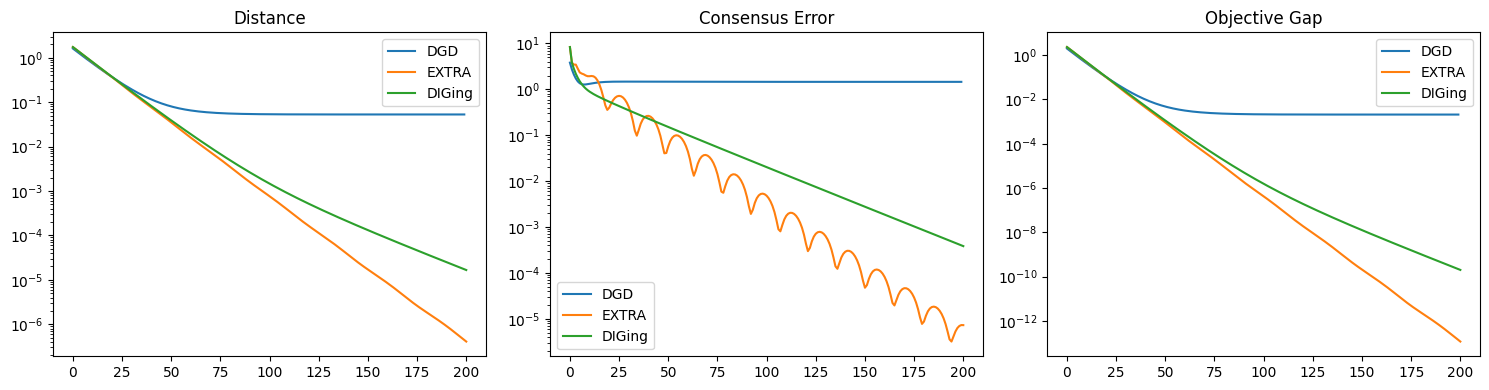

In [2]:
run_experiment()